In [13]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [7]:
leagues = pd.read_csv('../output/csvs/master_database.csv')
for col in ['c1*', 'c2*', 'c3*']:
    leagues[f'log_{col}'] = np.where(leagues[col] > 0, np.log(leagues[col]), np.nan)

C:\Users\ryanj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


**US Leagues**

In [15]:
us = leagues[leagues['type'] == "us"]

log_c1 = us['log_c1*']
log_c2 = us['log_c2*']
log_c3 = us['log_c3*']

NaNs — c1*: 0, c2*: 0, c3*: 0
Infs — c1*: 0, c2*: 0, c3*: 1
c1* vs c2*: r = 0.9688, p = 0.0000e+00
c1* vs c3*: r = 0.9767, p = 0.0000e+00
c2* vs c3*: r = 0.9674, p = 0.0000e+00


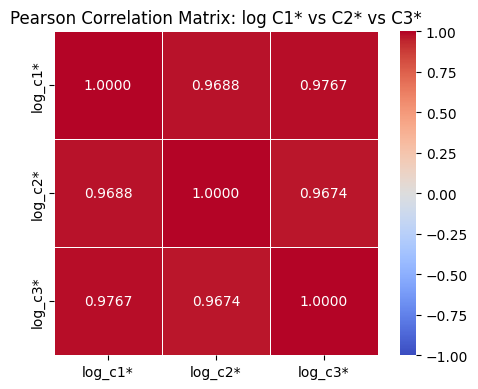

In [26]:
# Convert to numpy arrays (dropping NaNs pairwise)
v1 = log_c1.to_numpy()
v2 = log_c2.to_numpy()
v3 = log_c3.to_numpy()

print(f"NaNs — c1*: {np.isnan(v1).sum()}, c2*: {np.isnan(v2).sum()}, c3*: {np.isnan(v3).sum()}")
print(f"Infs — c1*: {np.isinf(v1).sum()}, c2*: {np.isinf(v2).sum()}, c3*: {np.isinf(v3).sum()}")

# Pairwise Pearson correlations
pairs = {'c1* vs c2*': (v1, v2), 'c1* vs c3*': (v1, v3), 'c2* vs c3*': (v2, v3)}
for name, (a, b) in pairs.items():
    mask = ~np.isnan(a) & ~np.isnan(b) & ~np.isinf(a) & ~np.isinf(b)
    r, p = pearsonr(a[mask], b[mask])
    print(f"{name}: r = {r:.4f}, p = {p:.4e}")

# Correlation matrix heatmap
corr_df = pd.DataFrame({'log_c1*': v1, 'log_c2*': v2, 'log_c3*': v3}).corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_df, annot=True, fmt=".4f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Pearson Correlation Matrix: log C1* vs C2* vs C3*")
plt.tight_layout()
# plt.savefig("../../output/figures/correlation_matrix.png", dpi=150)
plt.show()

**All Leagues**

NaNs — c1*: 1430, c2*: 2, c3*: 0
Infs — c1*: 0, c2*: 0, c3*: 1
log_c1* vs log_c2*: r = 0.9564, p = 0.0000e+00
log_c1* vs log_c3*: r = 0.9797, p = 0.0000e+00
log_c2* vs log_c3*: r = 0.9550, p = 0.0000e+00


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\ryanj\\OneDrive\\Desktop\\Projects\\output\\figures\\correlation_matrix.png'

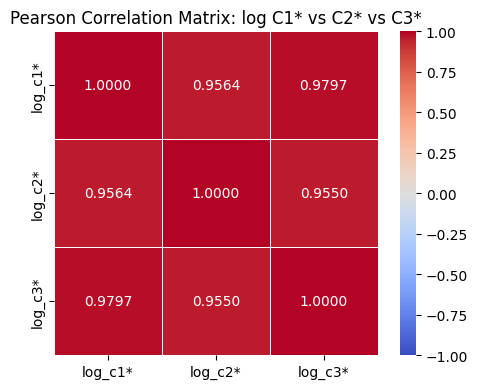